In [65]:
# Section 0: Setup
import urllib.request, zipfile, io, os, json, textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
import plotly.express as px
import plotly.graph_objects as go



pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)
# Force pandas to show regular floats instead of scientific notation
pd.set_option('display.float_format', lambda x: '%.2f' % x)


### China area codes across FAOSTAT datasets

| Code | Label | QCL (production) | TCL (trade) | TM (trade) | What it is |
|------|-------|:----------------:|:-----------:|:----------:|------------|
| **41** | China, mainland | ✅ | ✅ | ✅ | Mainland only — **the entity used** |
| 351 | China | ✅ | ✅ | ✅ | Aggregate: mainland + Taiwan + Hong Kong + Macao |
| 357 | China (mainland + Taiwan) | — | ✅ | ✅ | Aggregate: mainland + Taiwan (trade domains only) |
| 214 | China, Taiwan Province of | ✅ | ✅ | ✅ | Taiwan as a standalone territory |
| 96 | China, Hong Kong SAR | ✅ | ✅ | ✅ | Hong Kong as a standalone territory |
| 128 | China, Macao SAR | ✅ | ✅ | ✅ | Macao as a standalone territory |

**Why only code 41 (China, mainland):**

- **No double-counting** — 351 and 357 already contain the mainland, so keeping them alongside 41 counts mainland output/trade twice (the inflation bug seen in the production ranking).
- **Cross-dataset consistency** — production (QCL) is divided by trade (TCL/TM), so "China" must be the *same entity* in every file. Code 41 is the only China code present cleanly in all three; the aggregates differ by domain (351 everywhere, 357 trade-only).
- **Trade realism** — 351 bundles in Hong Kong, a major entrepôt whose re-export flows would inflate "China's" trade with goods that never originated on the mainland.
- **Stated scope** — 41 is mainland-only (excludes Taiwan 214, Hong Kong 96, Macao 128). Methodology note: **"China" = mainland, FAO code 41.**

In [2]:
# Section 0: Data principles, encoded as config so every downstream calc references the same
# assumptions instead of re-deciding them inline.
CONFIG = {
    # --- Scope for production ---
    'crop_item_code': 113,        # FAOSTAT Item Code for Rice (verified in Section 1)
    'crop_name': 'Rice',

   # --- Scope for trade ----
   # Rice with item code 113 (in QCL data) is not traded straight forward as 113, 
   # it inturn is traded in multiple forms (Rice;milled and Rice; milled (husked) as layer 1 and 2) 
   # and there is a conversion factor associated with this
   # Reference PDF: https://openknowledge.fao.org/server/api/core/bitstreams/63b8626c-7019-4f8c-a961-e975e7f9e285/content
   # Can be navigated from: https://openknowledge.fao.org/home
   # Keyed by the CPC code as it appears in Trade_CropsLivestock_E_ItemCodes.
   # The 
    'trade_crop_item_code_rm': 31,
    'trade_crop_name_rm' : 'Rice; milled', # Turns into broken rice (code 32)
    'rm_paddy_factor': 0.67,
    'trade_crop_item_code_rmh': 28,
    'trade_crop_name_rmh' : 'Husked rice', # turns into milled husked rice (code 29)
    'rmh_paddy_factor': 0.77,

    # --- Drop Area codes----
    # Excluding regional/continental aggregates (<5000)
    # Table above has an explaination about how China's area codes are represented in the FAOSTAT datset
    'aggregate_code_cutoff': 5000,
    'exclude_area_codes': [351, 357,214,96,128]
}
print(json.dumps({k: v for k, v in CONFIG.items() if k != 'water_stress_bins'}, indent=2, default=str))


{
  "crop_item_code": 113,
  "crop_name": "Rice",
  "trade_crop_item_code_rm": 31,
  "trade_crop_name_rm": "Rice; milled",
  "rm_paddy_factor": 0.67,
  "trade_crop_item_code_rmh": 28,
  "trade_crop_name_rmh": "Husked rice",
  "rmh_paddy_factor": 0.77,
  "aggregate_code_cutoff": 5000,
  "exclude_area_codes": [
    351,
    357,
    214,
    96,
    128
  ]
}


In [39]:
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Section 1a: Rice production — QCL bulk download

In [3]:
# Section 1a: QCL bulk download (Production: Crops and livestock products)
BULK_URL = 'https://bulks-faostat.fao.org/production/Production_Crops_Livestock_E_All_Data_(Normalized).zip'
if not os.path.exists('qcl_bulk.zip'):
    print('Downloading QCL bulk file...')
    urllib.request.urlretrieve(BULK_URL, 'qcl_bulk.zip')

with zipfile.ZipFile('qcl_bulk.zip') as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    print(f'Reading {csv_name}...')
    qcl_all = pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False)

    item_csv = [n for n in z.namelist() if 'ItemCodes' in n][0]
    item_codes = pd.read_csv(z.open(item_csv), encoding='latin-1')

    area_csv = [n for n in z.namelist() if 'AreaCodes' in n][0]
    area_codes = pd.read_csv(z.open(area_csv), encoding='latin-1')

print(f'Full QCL: {len(qcl_all):,} rows')

Reading Production_Crops_Livestock_E_All_Data_(Normalized).csv...
Full QCL: 4,209,110 rows


In [4]:
rice_matches = item_codes[item_codes['Item'].str.contains('Rice', case=False, na=False)][['Item Code', 'Item']]
print(rice_matches.to_string(index=False))

exact = rice_matches[rice_matches['Item'].str.fullmatch('Rice', case=False)]
if len(exact):
    CONFIG['crop_item_code'] = int(exact.iloc[0]['Item Code'])
else:
    print("No exact 'Rice' match in the lookup — check the table above and set CONFIG['crop_item_code'] manually.")
    CONFIG['crop_item_code'] = int(rice_matches.iloc[0]['Item Code'])  # best-effort fallback

print(f"Using Item Code {CONFIG['crop_item_code']} for Rice")

Item Code Item
       27 Rice
Using Item Code 27 for Rice


In [5]:
# Section 1c: filter to Rice Production (tonnes), then drop regional/continental aggregates (< 5000)
# AND the China aggregates/territories (keeping mainland 41 only, per CONFIG).
# Area Code isin() cast to str on both sides — the dtype mismatch here was the bug fixed in the
# original notebook's Section 3; keeping the cast explicit rather than trusting pandas to infer it.
qcl_rice = qcl_all[(qcl_all['Item Code'] == CONFIG['crop_item_code']) & (qcl_all['Element'] == 'Production')].copy()
print(f"Rice, Production element: {len(qcl_rice):,} rows, unit(s): {qcl_rice['Unit'].unique()}")
# print(qcl_rice.head())

# build the valid-country set: below the aggregate cutoff AND not an excluded China code
area_code_exclude = area_codes[
    (area_codes['Area Code'] < CONFIG['aggregate_code_cutoff'])
    & (~area_codes['Area Code'].isin(CONFIG['exclude_area_codes']))
]
valid_country_codes = set(area_code_exclude['Area Code'].astype(str))

qcl_rice = qcl_rice[qcl_rice['Area Code'].astype(str).isin(valid_country_codes)].copy()
print(f"After dropping aggregates + doubly counted codes (for China): {len(qcl_rice):,} rows, {qcl_rice['Area'].nunique()} countries")
# print(qcl_rice.head())

rice_by_area_year = qcl_rice.groupby(['Area', 'Area Code', 'Year'])['Value'].sum().reset_index(name='production_t')

Rice, Production element: 9,708 rows, unit(s): ['t']
After dropping aggregates + doubly counted codes (for China): 7,544 rows, 143 countries


In [6]:
world_production_over_year = rice_by_area_year.groupby('Year')['production_t'].sum().reset_index()
print(world_production_over_year)

    Year  production_t
0   1961  213069031.00
1   1962  223766003.00
2   1963  244444925.00
3   1964  260075174.00
4   1965  251074029.00
..   ...           ...
59  2020  769854053.78
60  2021  789501998.86
61  2022  777062081.24
62  2023  803284082.38
63  2024  818174842.58

[64 rows x 2 columns]


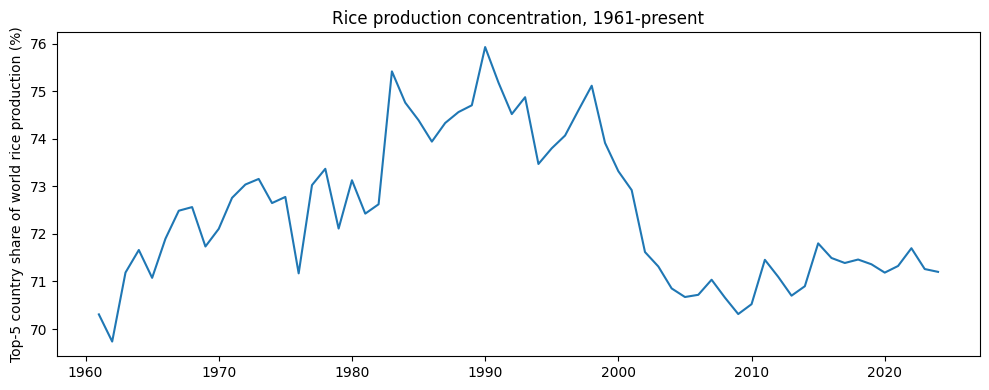

Latest top-5 share: 71.2%


In [7]:
# Full-history concentration trend (top-5 share of world production, year by year) — same metric
# as the original notebook's Section 4, recomputed here for Rice alone.
by_year_rank = rice_by_area_year.copy()
by_year_rank['rank'] = by_year_rank.groupby('Year')['production_t'].rank(ascending=False, method='min')

global_total_by_year = rice_by_area_year.groupby('Year')['production_t'].sum().reset_index(name='global_total')
top5_by_year = (by_year_rank[by_year_rank['rank'] <= 5]
                .groupby('Year')['production_t'].sum().reset_index(name='top5_total'))
concentration = top5_by_year.merge(global_total_by_year, on='Year')
concentration['top5_share_pct'] = concentration['top5_total'] / concentration['global_total'] * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(concentration['Year'], concentration['top5_share_pct'])
ax.set_ylabel('Top-5 country share of world rice production (%)')
ax.set_title('Rice production concentration, 1961-present')
plt.tight_layout(); plt.show()

print(f"Latest top-5 share: {concentration.sort_values('Year').iloc[-1]['top5_share_pct']:.1f}%")


#### Analysing the production (Total and Avg) for countries over a period of 2000-2024

In [8]:
#This is the total production analysis
rice_production_2000_2024 = (
    rice_by_area_year[
        (rice_by_area_year['Year'] >= 2000) &
        (rice_by_area_year['Year'] <= 2024)
    ]
    .groupby('Area')['production_t']
    .sum()
    .reset_index()
    .sort_values('production_t', ascending=False)
)

print(rice_production_2000_2024)

                                 Area  production_t
23                    China, mainland 4944787500.00
59                              India 3949568648.52
60                          Indonesia 1391403356.54
7                          Bangladesh 1209116494.14
138                          Viet Nam 1004997339.59
..                                ...           ...
99                             Poland          0.00
30                             Cyprus          0.00
111                          Slovakia          0.00
112                          Slovenia          0.00
107  Saint Vincent and the Grenadines          0.00

[141 rows x 2 columns]


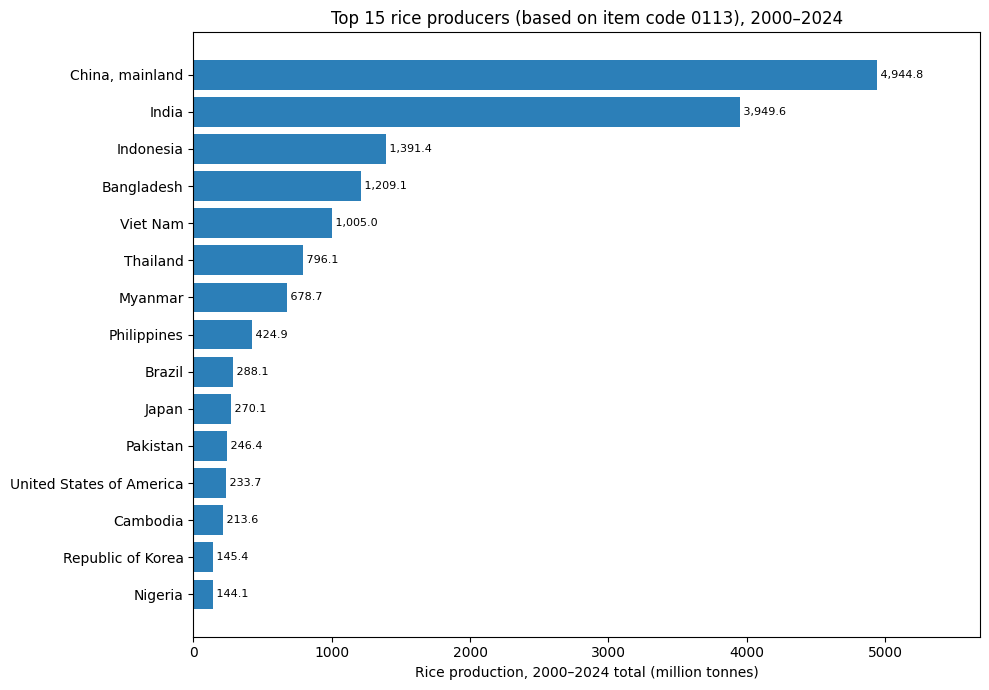

In [9]:
#Plotting the above data in bar-chart format
top = rice_production_2000_2024.nlargest(15, 'production_t').sort_values('production_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['production_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Rice production, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice producers (based on item code 0113), 2000–2024")

for y, v in enumerate(top['production_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

### Insights here:

**Two giants dominate.** China (4,944.8 Mt) and India (3,949.6 Mt) together produced ~8,894 Mt over 2000–2024 — more than the next 13 countries on this chart *combined*. Rice production is heavily top-heavy, not evenly spread.

**A steep drop after the top two.** #3 Indonesia (1,391.4 Mt) produces barely a quarter of China's output, and the chart falls off fast from there — Bangladesh (1,209.1) and Viet Nam (1,005.0) round out the only other billion-tonne-plus producers. Everyone below Thailand is under 800 Mt.

**Asia owns rice.** 13 of the top 15 producers are Asian; only Brazil (#9, 288.1 Mt) and the USA (#12, 233.7 Mt) break the pattern, and both sit far down the list. Rice production is geographically concentrated in South, Southeast, and East Asia.

**A long, flat tail.** From Myanmar (678.7 Mt) down to Nigeria (144.1 Mt), the bars cluster tightly at low values — a wide field of modest producers with no standout among them. Africa's largest rice grower (Nigeria) makes this list only at the very bottom.

### Takeaway
World rice production rests on a handful of Asian giants — China and India alone are the
backbone — with a steep cliff after the top few and a long tail of smaller producers. This
concentration matters for food security: output is dominated by countries that (as the
export analysis shows) mostly consume domestically, so the world's largest producers are
not its largest exporters.

#### Analysing, how does each countries production look at the global level by adding a pct_share_production and rank to each country solely for production
  This is essential for Section 2

In [10]:
# Add each country's share of total world cotton production, 2000-2024
rice_production_2000_2024['pct_share_production'] = (
    rice_production_2000_2024['production_t']
    / rice_production_2000_2024['production_t'].sum()
    * 100
)

# Re-sort and assign rank
rice_production_2000_2024 = (
    rice_production_2000_2024
    .sort_values('production_t', ascending=False)
    .reset_index(drop=True)
)

rice_production_2000_2024['rank'] = (
    rice_production_2000_2024.index + 1
)

print(rice_production_2000_2024)

                                 Area  production_t  pct_share_production  rank
0                     China, mainland 4944787500.00                 28.20     1
1                               India 3949568648.52                 22.52     2
2                           Indonesia 1391403356.54                  7.93     3
3                          Bangladesh 1209116494.14                  6.89     4
4                            Viet Nam 1004997339.59                  5.73     5
..                                ...           ...                   ...   ...
136                        Luxembourg          0.00                  0.00   137
137                           Germany          0.00                  0.00   138
138                           Belgium          0.00                  0.00   139
139                           Finland          0.00                  0.00   140
140  Saint Vincent and the Grenadines          0.00                  0.00   141

[141 rows x 4 columns]


In [11]:
#This is the average production 
avg_rice_production_2000_2024 = (
    rice_by_area_year[
        (rice_by_area_year['Year'] >= 2000) &
        (rice_by_area_year['Year'] <= 2024)
    ]
    .groupby('Area')['production_t']
    .mean()
    .reset_index()
    .sort_values('production_t', ascending=False)
)

print(avg_rice_production_2000_2024)

                                 Area  production_t
23                    China, mainland  197791500.00
59                              India  157982745.94
60                          Indonesia   55656134.26
7                          Bangladesh   48364659.77
138                          Viet Nam   40199893.58
..                                ...           ...
99                             Poland          0.00
30                             Cyprus          0.00
111                          Slovakia          0.00
112                          Slovenia          0.00
107  Saint Vincent and the Grenadines          0.00

[141 rows x 2 columns]


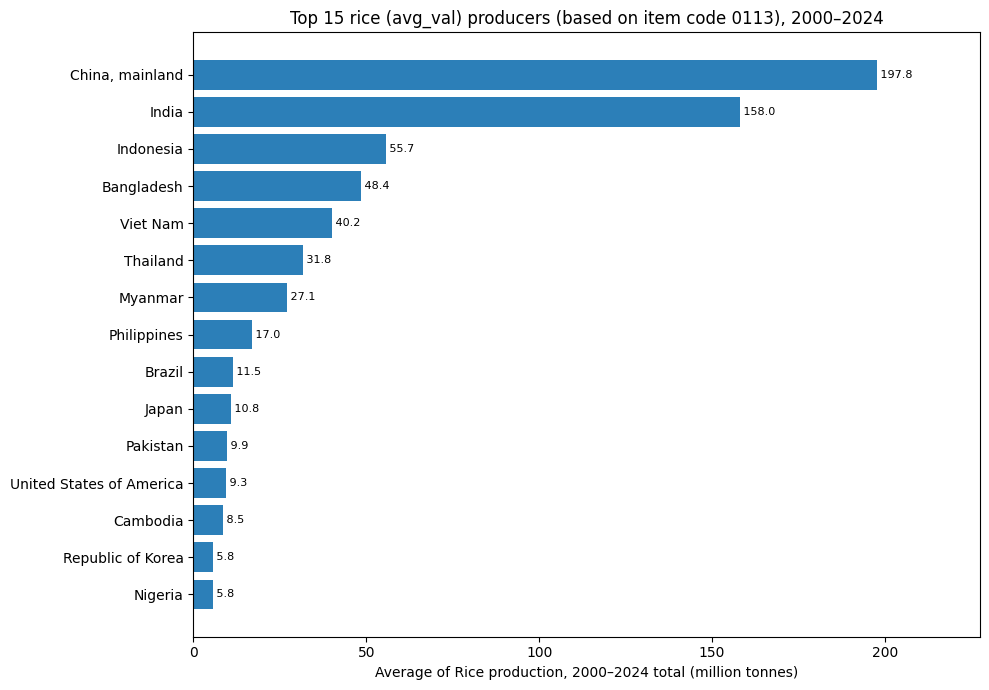

In [12]:
#Plotting the above data in bar-chart format
top = avg_rice_production_2000_2024.nlargest(15, 'production_t').sort_values('production_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['production_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Average of Rice production, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice (avg_val) producers (based on item code 0113), 2000–2024")

for y, v in enumerate(top['production_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

In [13]:
#Adding the world percentage values and ranks in terms of average production 
# This should almost match with teh total production above
avg_rice_production_2000_2024['pct_of_world'] = (
    avg_rice_production_2000_2024['production_t']
    / avg_rice_production_2000_2024['production_t'].sum() * 100
)

avg_rice_production_2000_2024 = avg_rice_production_2000_2024.reset_index(drop=True)
avg_rice_production_2000_2024['rank'] = avg_rice_production_2000_2024.index + 1

print(avg_rice_production_2000_2024)

                                 Area  production_t  pct_of_world  rank
0                     China, mainland  197791500.00         28.19     1
1                               India  157982745.94         22.52     2
2                           Indonesia   55656134.26          7.93     3
3                          Bangladesh   48364659.77          6.89     4
4                            Viet Nam   40199893.58          5.73     5
..                                ...           ...           ...   ...
136                            Poland          0.00          0.00   137
137                            Cyprus          0.00          0.00   138
138                          Slovakia          0.00          0.00   139
139                          Slovenia          0.00          0.00   140
140  Saint Vincent and the Grenadines          0.00          0.00   141

[141 rows x 4 columns]


<!-- ### How much of the rice is exported outside? And export/import analysis into one
1. Export share of production — How much of what it grows does it ship out?
Formula: export_share = export_qty ÷ production (done)

2. Net trade position - Is it a net seller or net buyer? (To do?)
Formula: net_exports = export_qty − import_qty  = 36,160.97 − 0.13 ≈ 36,160.84 t

3. apparent_supply = production − export_qty + import_qty (to-do?)

4. Self sufficieny ratio (SSR) (to-do?)
SSR = production ÷ (production − export_qty + import_qty)
SSR > 1 means the country grows more than it consumes (net exporter); SSR < 1 means it leans on imports. -->

 ### Section 1b: TCL data analysis: How much of produced rice enters international trade?

In [14]:
# TCL bulk download (Trade: Crops and livestock products)
BULK_URL = 'https://bulks-faostat.fao.org/production/Trade_CropsLivestock_E_All_Data_(Normalized).zip'
if not os.path.exists('tcl_bulk.zip'):
    print('Downloading TCL bulk file (~261 MB, a few minutes)...')
    urllib.request.urlretrieve(BULK_URL, 'tcl_bulk.zip')

with zipfile.ZipFile('tcl_bulk.zip') as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                and 'ItemCodes' not in n and 'AreaCodes' not in n
                and 'Elements' not in n][0]
    print(f'Reading {csv_name}...')
    tcl_all = pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False)

    item_csv = [n for n in z.namelist() if 'ItemCodes' in n][0]
    tcl_item_codes = pd.read_csv(z.open(item_csv), encoding='latin-1')

    area_csv = [n for n in z.namelist() if 'AreaCodes' in n][0]
    tcl_area_codes = pd.read_csv(z.open(area_csv), encoding='latin-1')

print(f'Full TCL: {len(tcl_all):,} rows')

Reading Trade_CropsLivestock_E_All_Data_(Normalized).csv...
Full TCL: 17,143,873 rows


In [15]:
print(tcl_all.head())

   Area Code Area Code (M49)         Area  Item Code Item Code (CPC)               Item  Element Code  \
0          2            '004  Afghanistan        221          '01371  Almonds, in shell          5610   
1          2            '004  Afghanistan        221          '01371  Almonds, in shell          5610   
2          3            '008      Albania        221          '01371  Almonds, in shell          5610   
3          4            '012      Algeria        221          '01371  Almonds, in shell          5610   
4          3            '008      Albania        221          '01371  Almonds, in shell          5610   

           Element  Year Code  Year Unit  Value Flag                                            Note  
0  Import quantity       2014  2014    t  34.46    X  Estimated data using trading partners database  
1  Import quantity       2015  2015    t  75.50    X  Estimated data using trading partners database  
2  Import quantity       1996  1996    t  87.00    A        

### Section 1b (1): Using code Item code 27 specifically as layer 1 for analysis: (Rice from QCL to rice in TCL)
This analysis isnt fair comparision since the code deosnt give the full picture, and the exporter quantity is very less for overall analysis, reference papers:
Reference PDF: https://openknowledge.fao.org/server/api/core/bitstreams/63b8626c-7019-4f8c-a961-e975e7f9e285/content (page 723)
https://openknowledge.fao.org/handle/20.500.14283/at163e (page 23)

In [17]:
# filter to Rice Production (tonnes), then drop regional/continental aggregates (< 5000)
# AND the China aggregates/territories (keeping mainland 41 only, per CONFIG).
tcl_rice = tcl_all[(tcl_all['Item Code'] == CONFIG['crop_item_code']) & (tcl_all['Element'] == 'Export quantity')].copy()
print(f"Rice, Export element: {len(tcl_rice):,} rows, unit(s): {tcl_rice['Unit'].unique()}")
print(tcl_rice.head())

# build the valid-country set: below the aggregate cutoff AND not an excluded China code
area_code_exclude = area_codes[
    (area_codes['Area Code'] < CONFIG['aggregate_code_cutoff'])
    & (~area_codes['Area Code'].isin(CONFIG['exclude_area_codes']))
]
valid_country_codes = set(area_code_exclude['Area Code'].astype(str))

tcl_rice = tcl_rice[tcl_rice['Area Code'].astype(str).isin(valid_country_codes)].copy()
print(f"After dropping aggregates + doubly counted codes (for China): {len(tcl_rice):,} rows, {tcl_rice['Area'].nunique()} countries")
# print(tcl_rice.head())

rice_by_area_year_traded_c27 = tcl_rice.groupby(['Area', 'Area Code', 'Year'])['Value'].sum().reset_index(name='exported_t')

Rice, Export element: 9,607 rows, unit(s): ['t']
         Area Code Area Code (M49)                                         Area  Item Code Item Code (CPC)  Item  \
422206         261       '097.1203  European Union (12) (excluding intra-trade)         27           '0113  Rice   
1206606        268       '097.2503  European Union (25) (excluding intra-trade)         27           '0113  Rice   
1206888        268       '097.2503  European Union (25) (excluding intra-trade)         27           '0113  Rice   
1207162        268       '097.2503  European Union (25) (excluding intra-trade)         27           '0113  Rice   
1668863        277            '728                                  South Sudan         27           '0113  Rice   

         Element Code          Element  Year Code  Year Unit   Value Flag  \
422206           5910  Export quantity       1994  1994    t 2278.00    E   
1206606          5910  Export quantity       2004  2004    t 1774.00    E   
1206888          5910  

In [18]:
rice_by_area_year_traded_c27

,Area,Area Code,Year,exported_t
0,Afghanistan,2,2016,64.74
1,Afghanistan,2,2023,0.05
2,Afghanistan,2,2024,1.50
3,Albania,3,1999,69.00
4,Albania,3,2000,5.00
...,...,...,...,...
6199,Zimbabwe,181,2010,60.00
6200,Zimbabwe,181,2011,30.00
6201,Zimbabwe,181,2012,158.00
6202,Zimbabwe,181,2013,0.00


In [19]:
# World rice traded per year in tonnes
world_trade_over_year = rice_by_area_year_traded_c27.groupby('Year')['exported_t'].sum().reset_index()
print(world_trade_over_year)

# #Export share
# export_share = (world_trade_over_year['exported_t']/world_production_over_year['production_t']) * 100
# print(export_share)


    Year  exported_t
0   1961   474204.00
1   1962   459180.00
2   1963   452447.00
3   1964   534113.00
4   1965   474455.00
..   ...         ...
59  2020  3141741.69
60  2021  3033079.68
61  2022  3074840.01
62  2023  4122433.33
63  2024  8128666.09

[64 rows x 2 columns]


#### Which countries exported the most rice (code 27) over the entire 2000–2024 period? 
Note: Top exporters, shown below are based on the the FAOSTAT Rice (0113 or Item code 27) trade classification.

In [20]:
#Total exports of rice (code 27) between 2000-2024
rice_exports_2000_2024_c27 = (
    rice_by_area_year_traded_c27[
        (rice_by_area_year_traded_c27['Year'] >= 2000) &
        (rice_by_area_year_traded_c27['Year'] <= 2024)
    ]
    .groupby('Area')['exported_t']
    .sum()
    .reset_index()
    .sort_values('exported_t', ascending=False)
)

print(rice_exports_2000_2024_c27)


                         Area  exported_t
160  United States of America 37913029.02
26                   Cambodia  6145726.02
21                     Brazil  5252875.33
69                      India  4332165.17
161                   Uruguay  1941181.21
..                        ...         ...
96           Marshall Islands        0.04
116          Papua New Guinea        0.00
88                      Libya        0.00
128     Saint Kitts and Nevis        0.00
153                   Tunisia        0.00

[168 rows x 2 columns]


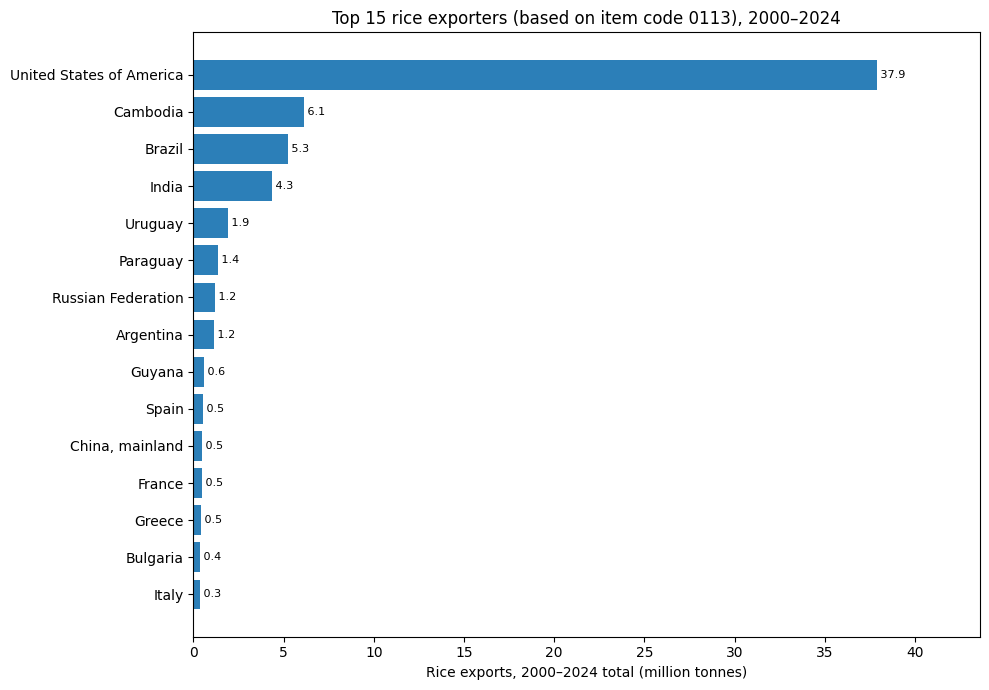

In [21]:
#Plotting the above data in bar chart
top = rice_exports_2000_2024_c27.nlargest(15, 'exported_t').sort_values('exported_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['exported_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Rice exports, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice exporters (based on item code 0113), 2000–2024")

for y, v in enumerate(top['exported_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

### Section 1b (1.2): Percentage and rank analysis for code 27 alone

In [22]:
# Add each country's share of total world cotton production, 2000-2024
rice_exports_2000_2024_c27['pct_share_export'] = (
    rice_exports_2000_2024_c27['exported_t']
    / rice_exports_2000_2024_c27['exported_t'].sum()
    * 100
)

# Re-sort and assign rank
rice_exports_2000_2024_c27 = (
    rice_exports_2000_2024_c27
    .sort_values('exported_t', ascending=False)
    .reset_index(drop=True)
)

rice_exports_2000_2024_c27['rank'] = (
    rice_exports_2000_2024_c27.index + 1
)

print(rice_exports_2000_2024_c27)

                         Area  exported_t  pct_share_export  rank
0    United States of America 37913029.02             58.71     1
1                    Cambodia  6145726.02              9.52     2
2                      Brazil  5252875.33              8.13     3
3                       India  4332165.17              6.71     4
4                     Uruguay  1941181.21              3.01     5
..                        ...         ...               ...   ...
163          Marshall Islands        0.04              0.00   164
164          Papua New Guinea        0.00              0.00   165
165                     Libya        0.00              0.00   166
166     Saint Kitts and Nevis        0.00              0.00   167
167                   Tunisia        0.00              0.00   168

[168 rows x 4 columns]


In [23]:
#Average exports of rice (code 27) between 2000-2024
average_rice_exports_2000_2024_c27 = (
    rice_by_area_year_traded_c27[
        (rice_by_area_year_traded_c27['Year'] >= 2000) &
        (rice_by_area_year_traded_c27['Year'] <= 2024)
    ]
    .groupby('Area')['exported_t']
    .mean()
    .reset_index()
    .sort_values('exported_t', ascending=False)
)

print(average_rice_exports_2000_2024_c27)


                         Area  exported_t
160  United States of America  1516521.16
26                   Cambodia   438980.43
21                     Brazil   210115.01
69                      India   173286.61
161                   Uruguay    77647.25
..                        ...         ...
5                     Armenia        0.03
153                   Tunisia        0.00
88                      Libya        0.00
128     Saint Kitts and Nevis        0.00
116          Papua New Guinea        0.00

[168 rows x 2 columns]


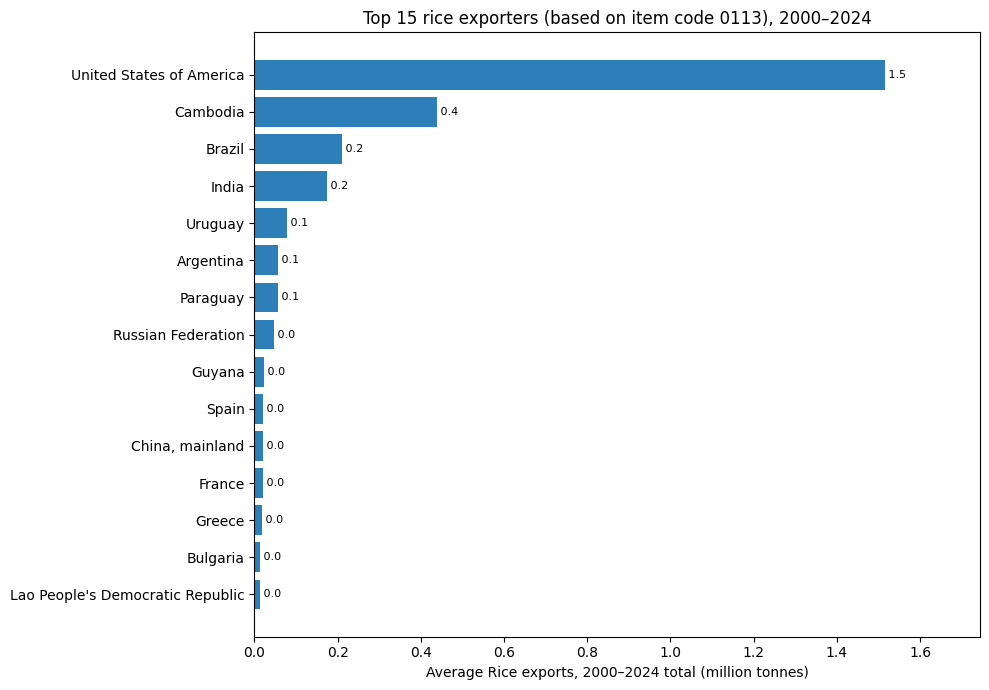

In [24]:
#Plotting the above data in bar chart
top = average_rice_exports_2000_2024_c27.nlargest(15, 'exported_t').sort_values('exported_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['exported_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Average Rice exports, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice exporters (based on item code 0113), 2000–2024")

for y, v in enumerate(top['exported_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

In [25]:
#Adding the world percentage values and ranks in terms of average production
#Similar to the totals above Section 1.b (1.2)
average_rice_exports_2000_2024_c27['pct_of_world'] = (
    average_rice_exports_2000_2024_c27['exported_t']
    / average_rice_exports_2000_2024_c27['exported_t'].sum() * 100
)

average_rice_exports_2000_2024_c27 = average_rice_exports_2000_2024_c27.reset_index(drop=True)
average_rice_exports_2000_2024_c27['rank'] = average_rice_exports_2000_2024_c27.index + 1

print(average_rice_exports_2000_2024_c27)

                         Area  exported_t  pct_of_world  rank
0    United States of America  1516521.16         53.85     1
1                    Cambodia   438980.43         15.59     2
2                      Brazil   210115.01          7.46     3
3                       India   173286.61          6.15     4
4                     Uruguay    77647.25          2.76     5
..                        ...         ...           ...   ...
163                   Armenia        0.03          0.00   164
164                   Tunisia        0.00          0.00   165
165                     Libya        0.00          0.00   166
166     Saint Kitts and Nevis        0.00          0.00   167
167          Papua New Guinea        0.00          0.00   168

[168 rows x 4 columns]


### Insights using original code for rice 27
USA which is the 12th largest producer for rice (0113), shows up as 1st largest exporter.
Out of (production amount code 27 for US) only 37.9 mT is being exported, that 

hence this code 0113 (Rice Item Code 27) is not a good comparision or rice production and trade, the by products of rice instead are based on the conversion factor

### Section 1b (2): Using code Item codes 31 and 28 specifically as layer 2 for analysis:
Rice from QCL to husked rice(code 28) and Milled paddy rice(code 31) in TCL
This analysis isnt fair comparision since the code doesnt give the full picture, reference papers:
Reference PDF: https://openknowledge.fao.org/server/api/core/bitstreams/63b8626c-7019-4f8c-a961-e975e7f9e285/content (page 723)
https://openknowledge.fao.org/handle/20.500.14283/at163e (page 23)

Using the code quivalents and conversions based on the PDF(Page 723) (https://openknowledge.fao.org/server/api/core/bitstreams/63b8626c-7019-4f8c-a961-e975e7f9e285/content)

In [26]:
#  filter TCL to the two rice trade items, Export quantity (tonnes), drop aggregates
# (< 5000) + China aggregates/territories, and lift each milled form to paddy-equivalent with its
# own factor before summing (per the ESSB commodity tree). Reads the flat config keys directly.

rm_code,  rm_factor  = CONFIG['trade_crop_item_code_rm'],  CONFIG['rm_paddy_factor']    # 31, 0.67, milled rice
rmh_code, rmh_factor = CONFIG['trade_crop_item_code_rmh'], CONFIG['rmh_paddy_factor']   # 28, 0.77, husked rice

tcl_rice = tcl_all[
    (tcl_all['Item Code'].isin([rm_code, rmh_code]))
    & (tcl_all['Element'] == 'Export quantity')
].copy()
print(f"Rice trade (export): {len(tcl_rice):,} rows, unit(s): {tcl_rice['Unit'].unique()}")
print(tcl_rice['Item'].unique())

# --- lift each form to paddy-equivalent using its own factor ---
tcl_rice['paddy_factor'] = tcl_rice['Item Code'].map({rm_code: rm_factor, rmh_code: rmh_factor})
# print(tcl_rice)
tcl_rice['exported_paddy_eq_t'] = tcl_rice['Value'] / tcl_rice['paddy_factor']
# print(tcl_rice)

# build the valid-country set: below the aggregate cutoff AND not an excluded China code
area_code_exclude = tcl_area_codes[
    (tcl_area_codes['Area Code'] < CONFIG['aggregate_code_cutoff'])
    & (~tcl_area_codes['Area Code'].isin(CONFIG['exclude_area_codes']))
]
valid_country_codes = set(area_code_exclude['Area Code'].astype(str))

tcl_rice = tcl_rice[tcl_rice['Area Code'].astype(str).isin(valid_country_codes)].copy()
print(f"After dropping aggregates + China double-counts: {len(tcl_rice):,} rows, {tcl_rice['Area'].nunique()} countries")

# sum paddy-equivalent tonnes across BOTH forms per country-year
rice_by_area_year_traded_conversion_based = (tcl_rice
    .groupby(['Area', 'Area Code', 'Year'])['exported_paddy_eq_t']
    .sum()
    .reset_index(name='exported_t'))

Rice trade (export): 21,415 rows, unit(s): ['t']
['Husked rice' 'Rice, milled']
After dropping aggregates + China double-counts: 14,599 rows, 202 countries


In [27]:
rice_by_area_year_traded_conversion_based

,Area,Area Code,Year,exported_t
0,Afghanistan,2,2014,0.67
1,Afghanistan,2,2015,99.73
2,Afghanistan,2,2018,26.24
3,Afghanistan,2,2019,9780.72
4,Afghanistan,2,2020,5.92
...,...,...,...,...
9248,Zimbabwe,181,2013,268.66
9249,Zimbabwe,181,2015,0.12
9250,Zimbabwe,181,2016,4.52
9251,Zimbabwe,181,2017,0.58


In [28]:
# World rice traded per year in tonnes
world_trade_yearwise = rice_by_area_year_traded_conversion_based.groupby('Year')['exported_t'].sum().reset_index()
print(world_trade_yearwise)


    Year  exported_t
0   1961  8693402.19
1   1962  9295728.34
2   1963 11155672.49
3   1964 11565785.06
4   1965 11400430.32
..   ...         ...
59  2020 59412189.41
60  2021 66119269.72
61  2022 71361298.67
62  2023 69459932.06
63  2024 73011224.85

[64 rows x 2 columns]


In [29]:
#Total rice exported for rice codes (31, 28) 
#Note the reason for selecting only these codes is in PDF link (page 723) above
rice_exports_2000_2024 = (
    rice_by_area_year_traded_conversion_based[
        (rice_by_area_year_traded_conversion_based['Year'] >= 2000) &
        (rice_by_area_year_traded_conversion_based['Year'] <= 2024)
    ]
    .groupby('Area')['exported_t']
    .sum()
    .reset_index()
    .sort_values('exported_t', ascending=False)
)

print(rice_exports_2000_2024)


                         Area   exported_t
83                      India 301872587.38
176                  Thailand 279124587.67
193                  Viet Nam 193667198.67
134                  Pakistan 116626353.88
188  United States of America  74451453.69
..                        ...          ...
109                  Maldives         0.10
39               Cook Islands         0.10
4         Antigua and Barbuda         0.01
164                   Somalia         0.00
56                    Eritrea         0.00

[197 rows x 2 columns]


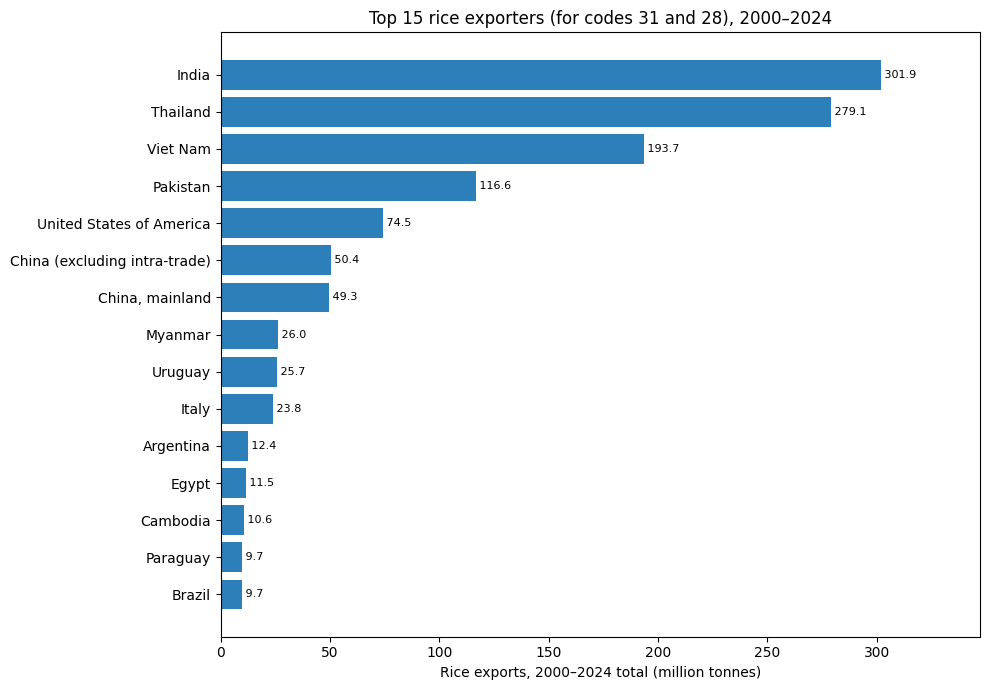

In [30]:
#Plotting the above in bar chart
top = rice_exports_2000_2024.nlargest(15, 'exported_t').sort_values('exported_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['exported_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Rice exports, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice exporters (for codes 31 and 28), 2000–2024")

for y, v in enumerate(top['exported_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

In [31]:
# Add each country's share of total world cotton production, 2000-2024
rice_exports_2000_2024['pct_share_export'] = (
    rice_exports_2000_2024['exported_t']
    / rice_exports_2000_2024['exported_t'].sum()
    * 100
)

# Re-sort and assign rank
rice_exports_2000_2024 = (
    rice_exports_2000_2024
    .sort_values('exported_t', ascending=False)
    .reset_index(drop=True)
)

rice_exports_2000_2024['rank'] = (
    rice_exports_2000_2024.index + 1
)

print(rice_exports_2000_2024)

                         Area   exported_t  pct_share_export  rank
0                       India 301872587.38             23.52     1
1                    Thailand 279124587.67             21.74     2
2                    Viet Nam 193667198.67             15.09     3
3                    Pakistan 116626353.88              9.09     4
4    United States of America  74451453.69              5.80     5
..                        ...          ...               ...   ...
192                  Maldives         0.10              0.00   193
193              Cook Islands         0.10              0.00   194
194       Antigua and Barbuda         0.01              0.00   195
195                   Somalia         0.00              0.00   196
196                   Eritrea         0.00              0.00   197

[197 rows x 4 columns]


In [32]:
#Average rice exported for rice codes (31, 28) 
#Note the reason for selecting only these codes is in PDF link (page 723) above
avg_rice_exports_2000_2024 = (
    rice_by_area_year_traded_conversion_based[
        (rice_by_area_year_traded_conversion_based['Year'] >= 2000) &
        (rice_by_area_year_traded_conversion_based['Year'] <= 2024)
    ]
    .groupby('Area')['exported_t']
    .mean()
    .reset_index()
    .sort_values('exported_t', ascending=False)
)

print(avg_rice_exports_2000_2024)

                         Area  exported_t
83                      India 12074903.50
176                  Thailand 11164983.51
193                  Viet Nam  7746687.95
134                  Pakistan  4665054.16
188  United States of America  2978058.15
..                        ...         ...
109                  Maldives        0.05
39               Cook Islands        0.05
4         Antigua and Barbuda        0.00
56                    Eritrea        0.00
164                   Somalia        0.00

[197 rows x 2 columns]


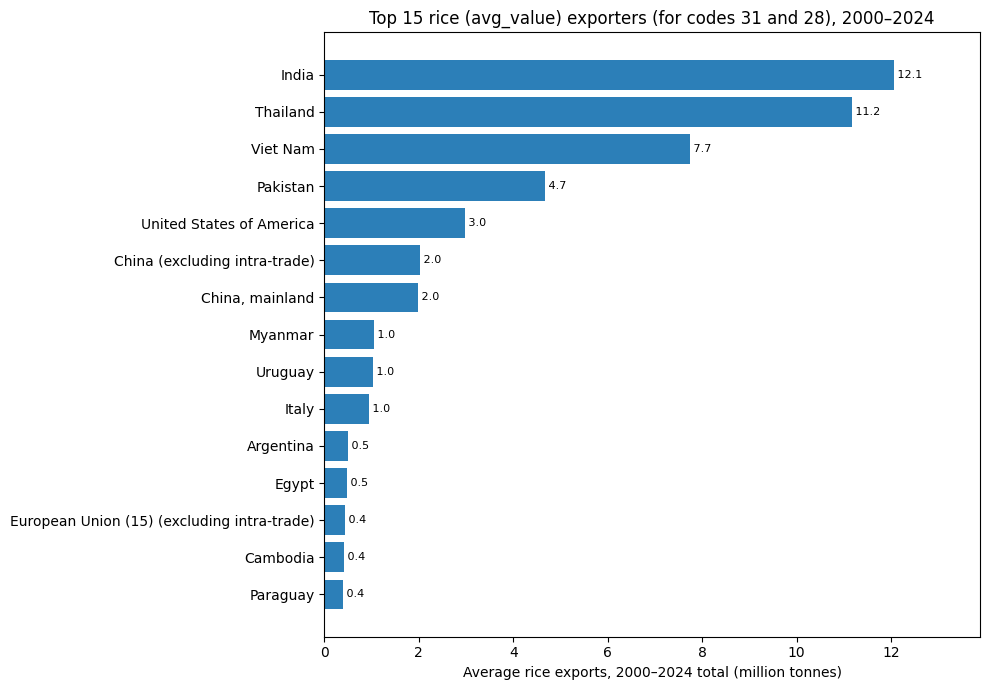

In [33]:
#Plotting the above in bar chart
top = avg_rice_exports_2000_2024.nlargest(15, 'exported_t').sort_values('exported_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['exported_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Average rice exports, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice (avg_value) exporters (for codes 31 and 28), 2000–2024")

for y, v in enumerate(top['exported_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

In [34]:
#Adding the world percentage values and ranks in terms of average production
avg_rice_exports_2000_2024['pct_share_export'] = (
    avg_rice_exports_2000_2024['exported_t']
    / avg_rice_exports_2000_2024['exported_t'].sum() * 100
)

avg_rice_exports_2000_2024 = avg_rice_exports_2000_2024.reset_index(drop=True)
avg_rice_exports_2000_2024['rank'] = avg_rice_exports_2000_2024.index + 1

print(avg_rice_exports_2000_2024)

                         Area  exported_t  pct_share_export  rank
0                       India 12074903.50             23.08     1
1                    Thailand 11164983.51             21.34     2
2                    Viet Nam  7746687.95             14.81     3
3                    Pakistan  4665054.16              8.92     4
4    United States of America  2978058.15              5.69     5
..                        ...         ...               ...   ...
192                  Maldives        0.05              0.00   193
193              Cook Islands        0.05              0.00   194
194       Antigua and Barbuda        0.00              0.00   195
195                   Eritrea        0.00              0.00   196
196                   Somalia        0.00              0.00   197

[197 rows x 4 columns]


### Insights 
Based on codes 28 and 31 the rice exports now shows the major producers as exporters and this makes sense for analysis since the original code 27 is not traded as is and hence choosing codes 28 and 31 for next steps

### Section 2: Production and Trade analysis countrywise to understand who are producing and who are exporting in one table
Understanding the production vs trade for each country and comparing each

In [35]:
print(rice_production_2000_2024.head())
print(rice_exports_2000_2024.head())

              Area  production_t  pct_share_production  rank
0  China, mainland 4944787500.00                 28.20     1
1            India 3949568648.52                 22.52     2
2        Indonesia 1391403356.54                  7.93     3
3       Bangladesh 1209116494.14                  6.89     4
4         Viet Nam 1004997339.59                  5.73     5
                       Area   exported_t  pct_share_export  rank
0                     India 301872587.38             23.52     1
1                  Thailand 279124587.67             21.74     2
2                  Viet Nam 193667198.67             15.09     3
3                  Pakistan 116626353.88              9.09     4
4  United States of America  74451453.69              5.80     5


# Note on this data analysis:
#### The pct_share_production represents the production share percentage for the country out of the total production
#### The pct_share_export represents the export share percentage for the country out of the total exports

#### Combining the two datasets to see who lies where in production vs export trends

Using full outer join because:
Countries that produce but barely export (China, Indonesia, Bangladesh) and countries that export a lot relative to production. An inner join keeps only countries present in both tables, which quietly drops:

Producers who don't export — if a country grows rice but has no export row, inner join deletes it. That erases the "self-consumer" category (Indonesia, Bangladesh) — the exact finding that makes China's behavior interesting.
Exporters/re-exporters who don't produce — a pure re-exporter (or a country whose production didn't survive filtering) would vanish too.

In [36]:
rice_production_export = rice_production_2000_2024[
    ['Area', 'production_t', 'pct_share_production', 'rank']
].merge(
    rice_exports_2000_2024[
        ['Area', 'exported_t', 'pct_share_export', 'rank']
    ],
    on='Area',
    how='outer',
    suffixes=('_production', '_export')
)
rice_production_export = rice_production_export.rename(columns={
    'rank_production': 'production_rank',
    'rank_export': 'export_rank'
}).sort_values('production_t', ascending=False)

print(rice_production_export.head(20))

                                 Area  production_t  pct_share_production  production_rank   exported_t  \
35                    China, mainland 4944787500.00                 28.20             1.00  49340060.38   
84                              India 3949568648.52                 22.52             2.00 301872587.38   
85                          Indonesia 1391403356.54                  7.93             3.00    110396.68   
12                         Bangladesh 1209116494.14                  6.89             4.00    227041.84   
196                          Viet Nam 1004997339.59                  5.73             5.00 193667198.67   
179                          Thailand  796109925.61                  4.54             6.00 279124587.67   
122                           Myanmar  678686540.00                  3.87             7.00  26031415.13   
141                       Philippines  424852212.51                  2.42             8.00      8579.51   
22                             Brazil

In [41]:
rice_production_export.to_csv(f'{OUTPUT_DIR}/rice_production_export.csv', index=False)

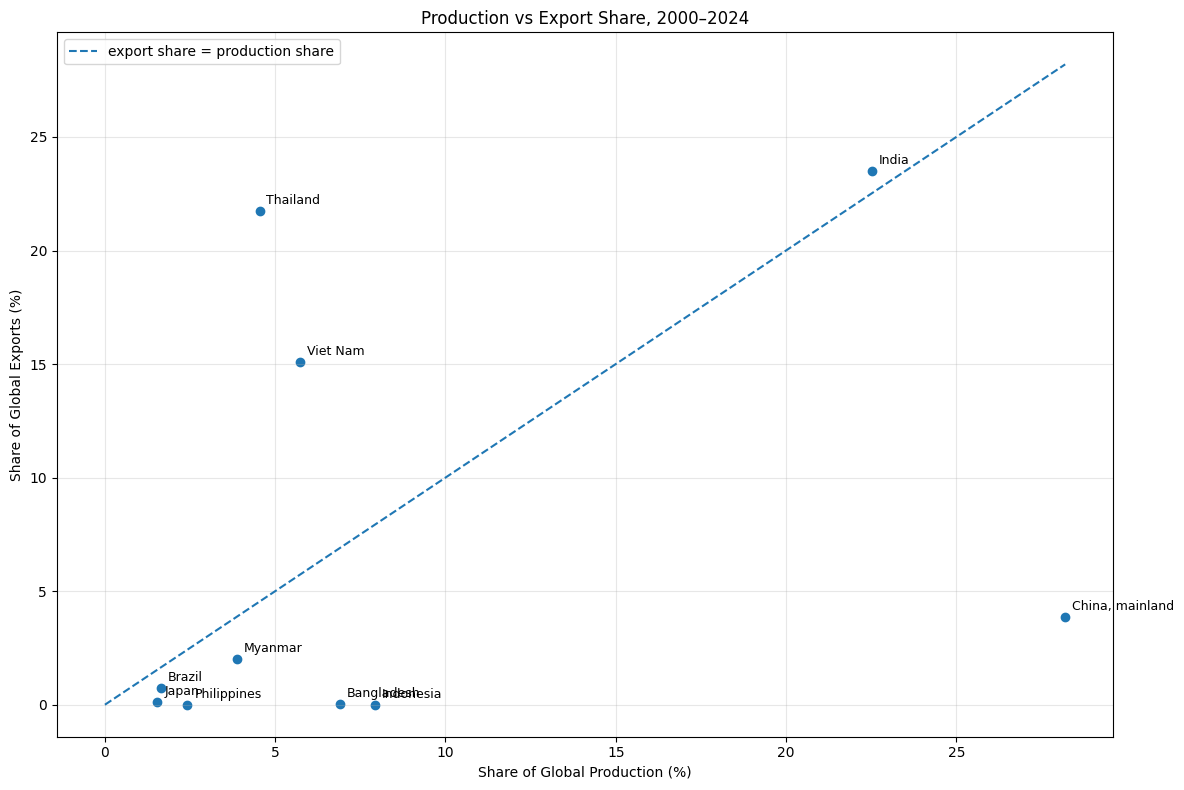

In [42]:
# Your merged production/export dataframe
plot_data = rice_production_export.copy()

# Keep top 10 producers
plot_data = (
    plot_data
    .sort_values('production_t', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 8))

plt.scatter(
    plot_data['pct_share_production'],
    plot_data['pct_share_export']
)

# Add country labels
for _, row in plot_data.iterrows():
    plt.annotate(
        row['Area'],
        (row['pct_share_production'], row['pct_share_export']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

# Add diagonal line: export share = production share
max_value = max(
    plot_data['pct_share_production'].max(),
    plot_data['pct_share_export'].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle='--',
    label='export share = production share'
)

plt.xlabel('Share of Global Production (%)')
plt.ylabel('Share of Global Exports (%)')
plt.title('Production vs Export Share, 2000–2024')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
plot_data = (
    rice_production_export
    .sort_values('production_t', ascending=False)
    .head(15)
    .copy()
)
plot_data['production_Mt'] = (plot_data['production_t'] / 1e6).round(1)   # for readable hover

fig = px.scatter(
    plot_data,
    x='pct_share_production',
    y='pct_share_export',
    size='production_t',                 # bubble size = ABSOLUTE production (tonnes)
    hover_name='Area',
    hover_data={
        'pct_share_production': ':.1f',
        'pct_share_export': ':.1f',
        'production_Mt': ':.1f',
        'production_t': False,           # hide the raw tonnes; show Mt instead
    },
    size_max=55,
    opacity=0.7,
)

fig.update_traces(marker=dict(color='#2C7FB8', line=dict(width=0.5, color='white')))
LABEL_OFFSETS = {'Indonesia': (30, 30), 'Bangladesh': (30, -30)}
for _, row in plot_data.iterrows():
    if row['pct_share_production'] >= 5 or row['pct_share_export'] >= 5:
        dx, dy = LABEL_OFFSETS.get(row['Area'], (14, 10))
        fig.add_annotation(
            x=row['pct_share_production'], y=row['pct_share_export'],
            text=row['Area'], showarrow=True, arrowwidth=0.8, arrowhead=0,
            ax=dx, ay=-dy, font=dict(size=12)
        )
# diagonal reference line
max_value = max(plot_data['pct_share_production'].max(),
                plot_data['pct_share_export'].max())
fig.add_shape(type='line', x0=0, y0=0, x1=max_value, y1=max_value,
              line=dict(dash='dash', width=1.5, color='grey'))

fig.update_layout(
    title='Rice Production vs. Export Share by Country, 2000–2024',
    xaxis_title='Share of Global Production (%)',
    yaxis_title='Share of Global Exports (%)',
    width=1000, height=700,
)

try:
    fig.write_image(f'{OUTPUT_DIR}/rice_production_vs_export.png', scale=2)
except Exception as e:
    print(f"PNG save skipped ({e}). Run: !pip install -U kaleido")
fig.show()

PNG save skipped (
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido
). Run: !pip install -U kaleido


### Insights here:

**Dual player — grows a lot AND exports a lot (on the diagonal):**

India:
1. Production share = 22.52%
2. Export share     = 23.10%
→ Only country strong on both. Top exporter, 2nd-largest producer. Exports roughly in proportion to its size.

**Export specialists — export far more than their production share (above the diagonal):**

Thailand:
1. Production share = 4.54%
2. Export share     = 21.48%
→ Grows little but ships most of it. ~5x more export share than production share.

Viet Nam:
1. Production share = 5.73%
2. Export share     = 14.83%
→ Built around rice for export. Punches ~2.5x above its production weight.

Pakistan:
1. Production share = 1.41%
2. Export share     = 8.99%
→ Small grower, major supplier. ~6x more export share than production share.

United States of America:
1. Production share = 1.33%
2. Export share     = 5.92%
→ Minor producer, meaningful exporter. Export-oriented rice sector.

**Self-consumers — grow enormous volumes, export almost nothing (far below the diagonal):**

China, mainland:
1. Production share = 28.20%
2. Export share     = 3.90%
→ World's largest producer, but keeps nearly all of it. Feeds its own population.

Indonesia:
1. Production share = 7.93%
2. Export share     = 0.01%
→ 3rd-largest producer, essentially zero exports.

Bangladesh:
1. Production share = 6.89%
2. Export share     = 0.02%
→ 4th-largest producer, negligible trade — entirely domestic.

### Takeaway
Many countries grow rice, but only a few export it. Production is spread across Asia
(China, India, Indonesia, Bangladesh, Vietnam, Thailand), while exports concentrate in
~4 countries (India, Thailand, Vietnam, Pakistan). The biggest producers (China,
Indonesia) barely trade — so if a top exporter like India restricts exports, the large
producers can't fill the gap, and global supply tightens fast.

### Section 3: Which Countries Matter for Trade? Export Dependence & Reporter Shortlisting
Export Readiness & Reporter Selection for Bilateral (TM) Analysis

#### Pre-TM Analysis To-Dos
##### Section 3(a)

1. Compute export share of production
export_share = exported_t ÷ production_t, per country.
Why it's essential: Absolute export volume alone is misleading — India and Thailand both export a lot, but Thailand ships most of what it grows while India exports a small slice of an enormous crop. The share tells you which countries are structurally dependent on exporting versus which merely happen to be large. This is the number that predicts how a country will behave in TM: high-share countries are the ones whose outbound flows carry real global supply-chain weight, and whose export bans (like India's) ripple hardest.

In [45]:
trade_df = rice_production_export.copy()

#### Based on the dataframe few trends emerge about production, export and re-export

Data cleanup essentials before computing 1 and 2 above
1. Resolve the zero/null-production rows
59 countries have null production rank and many have production_t = 0; only 141 of 200 actually produce.
Why it's essential: These are outer-join artifacts, and if left unhandled they propagate silently into the TM layer — producing divide-by-zero errors in export share.

2. Flag producers vs. re-exporters
Separate countries that grow rice (production > 0) from those that export without producing (production = 0, exports > 0).
Why it's essential:
A re-exporter is a country that ships out rice it never grew — it bought the rice from another country, then sold it onward to a third country. The rice passes through it, rather than originating there.

The mechanism, step by step:

Country A grows rice (real production).
Country B buys rice from A → this is an import for B.
Country B sells that same rice to Country C → this is an export for B.

In [46]:
#1 —  Compute export share of production + producer/re-exporter classification

REEXPORT_THRESHOLD = 130   # % — export share above this = functionally a re-exporter
                           # (grows a token amount but exports far more than it produces)
                           # This ratio is based on 

# --- Step 1: separate the zero-production countries first ---
producers   = trade_df[trade_df['production_t'] > 0].copy()          # real producers (has crop)
reexporters = trade_df[(trade_df['production_t'] == 0) &
                       (trade_df['exported_t'] > 0)].copy()          # export but don't grow
inactive    = trade_df[(trade_df['production_t'] == 0) &
                       (trade_df['exported_t'] == 0)].copy()         # neither — drop

# --- Step 2: export share, computed only where production > 0 ---
#export_ratio_of_production = what fraction of the rice a country grows that it exports
producers['export_ratio_of_production'] = producers['exported_t'] / producers['production_t'] * 100

# --- Step 3: catch DISGUISED re-exporters ---
# some countries grow a tiny amount but export 10-70x their output (e.g. Saudi Arabia,
# South Africa) — token production let them slip past the ==0 filter. Reclassify by threshold.
disguised = producers[producers['export_ratio_of_production'] > REEXPORT_THRESHOLD].copy()
disguised['note'] = 're-exporter (token production, exports >> output)'

# keep only genuine producers (export share within a plausible range)
producers = producers[producers['export_ratio_of_production'] <= REEXPORT_THRESHOLD].copy()

# --- Step 4: label the true re-exporters (zero-production) and fold in the disguised ones ---
reexporters['export_ratio_of_production'] = pd.NA
reexporters['note'] = 're-exporter (no domestic production)'
reexporters = pd.concat([reexporters, disguised], ignore_index=True)

# --- Step 5: label the inactive countries ---
inactive['export_ratio_of_production'] = pd.NA
inactive['note'] = 'neither produces nor exports'

# --- sanity checks ---
print(f"producers:   {len(producers)}")
print(f"re-exporters: {len(reexporters)}  (zero-production + disguised)")
print(f"inactive:    {len(inactive)}")
print("\nDisguised re-exporters moved out of producers:")
print(disguised[['Area', 'production_t', 'exported_t', 'export_ratio_of_production']].to_string(index=False))
print("\nGenuine producers with export share > 100% (legit stock/re-export):")
print(producers[producers['export_ratio_of_production'] > 100]
      [['Area', 'production_t', 'exported_t', 'export_ratio_of_production']].to_string(index=False))

producers:   113
re-exporters: 25  (zero-production + disguised)
inactive:    0

Disguised re-exporters moved out of producers:
        Area  production_t  exported_t  export_ratio_of_production
South Africa      77110.62  1779064.79                     2307.16
Saudi Arabia       4747.75   296588.65                     6246.93
   Mauritius       4188.00    37625.56                      898.41
     Jamaica       1296.30     2551.68                      196.84

Genuine producers with export share > 100% (legit stock/re-export):
Empty DataFrame
Columns: [Area, production_t, exported_t, export_ratio_of_production]
Index: []


/var/folders/1r/6nts2hsj4tbdxxzj39hbr34r0000gn/T/ipykernel_96843/3757565369.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  reexporters = pd.concat([reexporters, disguised], ignore_index=True)


In [47]:
# --- Combine into one labelled frame ---
producers['category']   = 'producer'
reexporters['category']  = 're-exporter'
inactive['category']     = 'inactive'

trade_classified = pd.concat([producers, reexporters, inactive], ignore_index=True)

# drop the note column — category already carries the classification
trade_classified = trade_classified.drop(columns='note', errors='ignore')

print(trade_classified['category'].value_counts())
print(f"total countries: {len(trade_classified)}")

category
producer       113
re-exporter     25
Name: count, dtype: int64
total countries: 138


/var/folders/1r/6nts2hsj4tbdxxzj39hbr34r0000gn/T/ipykernel_96843/3238620066.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trade_classified = pd.concat([producers, reexporters, inactive], ignore_index=True)


In [48]:
trade_classified

,Area,production_t,pct_share_production,production_rank,exported_t,pct_share_export,export_rank,export_ratio_of_production,category
0,"China, mainland",4944787500.00,28.20,1.00,49340060.38,3.84,7.00,1.00,producer
1,India,3949568648.52,22.52,2.00,301872587.38,23.52,1.00,7.64,producer
2,Indonesia,1391403356.54,7.93,3.00,110396.68,0.01,71.00,0.01,producer
3,Bangladesh,1209116494.14,6.89,4.00,227041.84,0.02,61.00,0.02,producer
4,Viet Nam,1004997339.59,5.73,5.00,193667198.67,15.09,3.00,19.27,producer
...,...,...,...,...,...,...,...,...,...
133,Saint Vincent and the Grenadines,0.00,0.00,141.00,100343.58,0.01,73.00,NaN,re-exporter
134,South Africa,77110.62,0.00,104.00,1779064.79,0.14,28.00,2307.16,re-exporter
135,Saudi Arabia,4747.75,0.00,116.00,296588.65,0.02,57.00,6246.93,re-exporter
136,Mauritius,4188.00,0.00,117.00,37625.56,0.00,92.00,898.41,re-exporter


#### Section Selecting Reporter Countries for the Trade-Flow (TM) Analysis

**What this does:** Narrows the full country list down to a shortlist of major, genuine
rice exporters that are worth mapping in the bilateral Detailed Trade Matrix (TM) — the
"who ships to whom" layer.

**Why it's needed:** TM data explodes into reporter × partner pairs (every exporter against
every buyer), so mapping all 200 countries is neither feasible nor meaningful — most would
be noise. We need a small, defensible set of reporters that actually drive world rice trade.

**The selection rule (three filters):**
1. `category == 'producer'` — keep only true sources. Excludes re-exporters (e.g. Saudi
   Arabia, South Africa) so we don't mis-attribute the *origin* of rice they merely
   pass through.
2. `exported_t > 1 Mt` — keep only meaningful volumes. Drops trivial exporters whose
   bilateral flows would be statistical noise.
3. `export_ratio_of_production > 5%` — keep only genuinely export-*oriented* countries

**Result:** a reproducible reporter shortlist (expected: India, Thailand, Vietnam, Pakistan,
USA, Myanmar, Cambodia, Brazil) that feeds the next layer — mapping each exporter's top
destination markets and the dependency of importing countries on them.

In [49]:
# only genuine producers that are real, export-oriented exporters
shortlist = trade_classified[
    (trade_classified['category'] == 'producer') &   # true sources, not re-exporters
    (trade_classified['exported_t'] > 1e6) &         # meaningful volume (>1 Mt paddy-eq)
    (trade_classified['export_ratio_of_production'] > 5)       # actually export-oriented, 5 is set arbitarily right now, can be updated
].sort_values('exported_t', ascending=False)

print(shortlist[['Area', 'exported_t', 'export_ratio_of_production',
                 'pct_share_export', 'export_rank']].to_string(index=False))
print(f"\n{len(shortlist)} reporters selected for TM analysis")

                       Area   exported_t  export_ratio_of_production  pct_share_export  export_rank
                      India 301872587.38                        7.64             23.52         1.00
                   Thailand 279124587.67                       35.06             21.74         2.00
                   Viet Nam 193667198.67                       19.27             15.09         3.00
                   Pakistan 116626353.88                       47.33              9.09         4.00
   United States of America  74451453.69                       31.86              5.80         5.00
                    Uruguay  25658268.91                       80.96              2.00         9.00
                      Italy  23786313.70                       65.52              1.85        10.00
                  Argentina  12429852.37                       40.16              0.97        11.00
                      Egypt  11533929.86                        8.33              0.90        12.00


#### Using the list of countries from above for TM (reporter/partner) analysis that feeds to water stress analysis

In [50]:
BULK_URL = 'https://bulks-faostat.fao.org/production/Trade_DetailedTradeMatrix_E_All_Data_(Normalized).zip'
if not os.path.exists('tm_bulk.zip'):
    print('Downloading TM bulk (~400 MB zip / ~1.5 GB unzipped)...')
    urllib.request.urlretrieve(BULK_URL, 'tm_bulk.zip')


REPORTERS = shortlist['Area'].tolist()

ITEM_CODES = [28,31]              # code 30 (consistent with your pipeline); switch to [28,31] if 30 is empty
ELEMENTS   = [5910]           # Export quantity (reporter's exports TO each partner)
YEAR_MIN, YEAR_MAX = 2000, 2024

with zipfile.ZipFile('tm_bulk.zip') as z:
    def is_meta(n):
        low = n.lower().replace('_', '')
        return any(k in low for k in ('flags', 'itemcodes', 'elements',
                                      'countrycodes', 'areacodes'))
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and not is_meta(n)][0]
    print(f'Streaming {csv_name}...')

    parts = []
    for chunk in pd.read_csv(z.open(csv_name), encoding='latin-1',
                             low_memory=False, chunksize=1_000_000):
        chunk.columns = [c.strip() for c in chunk.columns]
        chunk['Item Code']    = pd.to_numeric(chunk['Item Code'], errors='coerce')
        chunk['Element Code'] = pd.to_numeric(chunk['Element Code'], errors='coerce')
        chunk['Year']         = pd.to_numeric(chunk['Year'], errors='coerce')

        m = (
            chunk['Reporter Countries'].isin(REPORTERS)
            & chunk['Item Code'].isin(ITEM_CODES)
            & chunk['Element Code'].isin(ELEMENTS)
            & chunk['Year'].between(YEAR_MIN, YEAR_MAX)
        )
        if m.any():
            parts.append(chunk.loc[m])

    if not parts:
        raise ValueError("No rows matched — check reporter spelling / item code coverage.")
    tm_rice = pd.concat(parts, ignore_index=True)

# --- confirm every reporter was actually found (catches spelling/encoding drops) ---
found = set(tm_rice['Reporter Countries'].unique())
missing = [r for r in REPORTERS if r not in found]
print(f"\nrows: {len(tm_rice):,}   reporters found: {len(found)}/{len(REPORTERS)}")
if missing:
    print("!! not found (check spelling in the TM file):", missing)

Streaming Trade_DetailedTradeMatrix_E_All_Data_(Normalized).csv...

rows: 38,472   reporters found: 24/24


##### Note: 
Since this notebook is looking at code 28 and 31, most of these values are official/imputed and hence will have only Export values as offical and imputed

In [54]:
# print(((tm_rice['Flag'] == 'A') | (tm_rice['Flag'] == 'I')).any())
# tm_rice[tm_rice['Flag'] == 'I'] 

In [55]:
tm_rice.head()

,Reporter Country Code,Reporter Country Code (M49),Reporter Countries,Partner Country Code,Partner Country Code (M49),Partner Countries,Item Code,Item Code (CPC),Item,Element Code,Element,Year Code,Year,Unit,Value,Flag
0,91,'328,Guyana,7,'024,Angola,28,'23162,Husked rice,5910,Export quantity,2024,2024,t,11000.00,A
1,169,'600,Paraguay,3,'008,Albania,31,'23161.02,"Rice, milled",5910,Export quantity,2018,2018,t,520.00,A
2,9,'032,Argentina,3,'008,Albania,28,'23162,Husked rice,5910,Export quantity,2009,2009,t,0.00,A
3,169,'600,Paraguay,4,'012,Algeria,31,'23161.02,"Rice, milled",5910,Export quantity,2018,2018,t,26.00,A
4,234,'858,Uruguay,3,'008,Albania,31,'23161.02,"Rice, milled",5910,Export quantity,2008,2008,t,1008.00,A


#### Who buys how much from each related table:

In [62]:
# # total export quantity from each reporter to each partner, 2000-2024
# flows = (tm_rice.groupby(['Reporter Countries', 'Partner Countries'])['Value']
#                 .sum().reset_index(name='export_qty_t'))

# # print(flows.head())

# # top 25 buyers for each reporter
# top_buyers = (flows.sort_values(['Reporter Countries', 'export_qty_t'], ascending=[True, False])
#                    .groupby('Reporter Countries').head(25))

# top_buyers

In [66]:
# total export quantity from each reporter to each partner, 2000-2024
flows = (tm_rice.groupby(['Reporter Countries', 'Partner Countries'])['Value']
                .sum().reset_index(name='export_qty_t'))

# each partner's total imports from your reporter set (the denominator)
partner_totals = (flows.groupby('Partner Countries')['export_qty_t']
                       .transform('sum'))

# dependency: what share of this partner's imports (from your reporters) come from this reporter
flows['dependency_pct'] = (flows['export_qty_t'] / partner_totals * 100).round(1)

flows['export_qty_t'] = (flows['export_qty_t'] / 1e6).round(2)

# sort by flow size, then dependency, both descending
flows = flows.sort_values(['export_qty_t', 'dependency_pct'],
                          ascending=[False, False]).reset_index(drop=True)

print(flows.head(30).to_string(index=False))
# print(flows.to_string(index=False))

      Reporter Countries          Partner Countries  export_qty_t  dependency_pct
                   India               Saudi Arabia         21.66           72.40
                Viet Nam                Philippines         18.79           64.70
                Viet Nam            China, mainland         15.13           50.00
                Thailand                      Benin         15.02           49.70
                   India Iran (Islamic Republic of)         14.97           61.70
                Thailand               South Africa         14.59           65.70
                   India                 Bangladesh         14.19           84.50
                Thailand                    Nigeria         14.01           69.40
                   India                      Benin         13.32           44.00
                   India       United Arab Emirates         11.75           60.40
                Thailand   United States of America         11.65           70.70
                

In [70]:
# --- filter to the flows worth showing ---
# keep meaningful flows only, then top N, or you'll get spaghetti
top = flows[flows['export_qty_t'] > 5.0].nlargest(20, 'export_qty_t').copy()   # >0.1 Mt, top 20

# --- build node list (reporters + partners as distinct nodes) ---
# suffix so a country that's both a reporter and a partner doesn't collapse into one node
reporters = top['Reporter Countries'].unique().tolist()
partners  = top['Partner Countries'].unique().tolist()
r_nodes = [f"{r} (exp)" for r in reporters]
p_nodes = [f"{p} (imp)" for p in partners]
labels  = r_nodes + p_nodes
idx = {name: i for i, name in enumerate(labels)}

# --- edges ---
source = [idx[f"{r} (exp)"] for r in top['Reporter Countries']]
target = [idx[f"{p} (imp)"] for p in top['Partner Countries']]
value  = top['export_qty_t'].tolist()

fig = go.Figure(go.Sankey(
    node=dict(label=labels, pad=15, thickness=18,
              color=['#2C7FB8']*len(r_nodes) + ['#D95F02']*len(p_nodes)),
    link=dict(source=source, target=target, value=value,
              hovertemplate='%{source.label} → %{target.label}<br>%{value:.2f} Mt<extra></extra>')
))
fig.update_layout(title_text="Rice export flows (based on highest export quantity (Mt)): exporters → importers (top 20, >5 Mt)",
                  font_size=11, height=800)
fig.show()

In [71]:
#Individual country analysis
print(flows[flows['Reporter Countries'] == 'Viet Nam']
      .sort_values('dependency_pct', ascending=False)
      [['Partner Countries', 'export_qty_t', 'dependency_pct']].to_string(index=False))

                                   Partner Countries  export_qty_t  dependency_pct
                                     Solomon Islands          0.07           90.60
                                             Vanuatu          0.04           80.40
                                         Philippines         18.79           64.70
                                    Marshall Islands          0.02           63.80
                                            Cambodia          0.17           52.30
                                     China, mainland         15.13           50.00
                                               Ghana          5.05           47.80
                                            Kiribati          0.02           43.20
                                         Timor-Leste          0.40           36.70
                                            Malaysia          5.65           30.50
                                           Indonesia          4.44           29.50
    

In [80]:
# partner_total_from_reporters:
#   For each partner (importing) country, the SUM of rice it imported from ALL of your
#   shortlist reporters combined. This is the DENOMINATOR for dependency — note it is
#   "imports from your reporter set," NOT the partner's total imports from the whole world.
partner_totals = (flows.groupby('Partner Countries')['export_qty_t']
                       .sum().reset_index(name='partner_total_from_reporters'))

# dependency:
#   flows (one row per reporter->partner pair) joined to each partner's total-from-reporters,
#   so every row now carries both the individual flow AND the partner's overall intake.
dependency = flows.merge(partner_totals, on='Partner Countries')

# dependency_pct:
#   What share (%) of this partner's imports-from-reporters comes from THIS one reporter.
#   e.g. India->Benin 800t / Benin's 1000t total = 80% -> Benin is 80% dependent on India.
#   Rounded to 1 decimal. (Share of TRACKED exporters, not of all world imports.)
dependency['dependency_pct'] = (
    dependency['export_qty_t'] / dependency['partner_total_from_reporters'] * 100
).round(1)

# sort:
#   group rows by partner, and within each partner put the HIGHEST dependency first,
#   so each buyer's dominant supplier sits at the top of its block.
dependency = dependency.sort_values(
    ['Partner Countries', 'dependency_pct'], ascending=[True, False]
).reset_index(drop=True)

# save the four key columns:
#   Partner Countries  -> the importing country (buyer)
#   Reporter Countries -> the exporting country (supplier)
#   export_qty_t       -> tonnes this reporter shipped to this partner (summed over years)
#   dependency_pct     -> % of the partner's reporter-imports that came from this reporter
dependency.to_csv(
    f'{OUTPUT_DIR}/Reporter_Partner_Export_Dependency_28_31.csv',
    columns=['Partner Countries', 'Reporter Countries', 'export_qty_t', 'dependency_pct'],
    index=False   # added: otherwise an unnamed index column is written
)

print(dependency[['Partner Countries', 'Reporter Countries',
                  'export_qty_t', 'dependency_pct']].to_string(index=False))

                                   Partner Countries          Reporter Countries  export_qty_t  dependency_pct
                                         Afghanistan                    Pakistan          4.67           98.30
                                         Afghanistan                       India          0.03            0.60
                                         Afghanistan    United States of America          0.03            0.60
                                         Afghanistan                       Italy          0.01            0.20
                                         Afghanistan                  Kazakhstan          0.01            0.20
                                         Afghanistan                      France          0.00            0.00
                                         Afghanistan          Russian Federation          0.00            0.00
                                         Afghanistan                       Spain          0.00            0.00
 

In [81]:
dependency.head()

,Reporter Countries,Partner Countries,export_qty_t,dependency_pct,partner_total_from_reporters
0,Pakistan,Afghanistan,4.67,98.30,4.75
1,India,Afghanistan,0.03,0.60,4.75
2,United States of America,Afghanistan,0.03,0.60,4.75
3,Italy,Afghanistan,0.01,0.20,4.75
4,Kazakhstan,Afghanistan,0.01,0.20,4.75


In [82]:
understand_Water_risk_reporter = sorted(dependency['Reporter Countries'].unique().tolist())
understand_Water_risk_partner  = sorted(dependency['Partner Countries'].unique().tolist())

print(f"reporters ({len(understand_Water_risk_reporter)}):")
print(understand_Water_risk_reporter)
print(f"\npartners ({len(understand_Water_risk_partner)}):")
print(understand_Water_risk_partner)

#common = sorted(set(understand_Water_risk_reporter) & set(understand_Water_risk_partner))
# print(f"{len(common)} countries appear as BOTH exporter and buyer:")
# print(common)
# 29 countries appear as BOTH exporter and buyer:
# ['Argentina', 'Australia', 'Benin', 'Brazil', 'Bulgaria', 'Cambodia', 'Egypt', 'France', 'Greece', 'Guyana', 'India', 'Italy', 'Kazakhstan', 'Myanmar', 'Niger', 'Pakistan', 'Paraguay', 'Portugal', 'Russian Federation', 'Senegal', 'Spain', 'Suriname', 'Thailand', 'TÃ¼rkiye', 'Uganda', 'United Republic of Tanzania', 'United States of America', 'Uruguay', 'Viet Nam']

reporters (24):
['Argentina', 'Australia', 'Benin', 'Bulgaria', 'Egypt', 'France', 'Greece', 'Guyana', 'India', 'Italy', 'Kazakhstan', 'Niger', 'Pakistan', 'Paraguay', 'Portugal', 'Russian Federation', 'Spain', 'Suriname', 'Thailand', 'TÃ¼rkiye', 'United Republic of Tanzania', 'United States of America', 'Uruguay', 'Viet Nam']

partners (199):
['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia (Plurinational State of)', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', 'China, Hong Kong SAR', 'China, Macao SAR', 'China, Taiwan Province of', 'China, mainland', 'Colombia', 'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'C

#### Up next Heidi to understand water risk/indicator for countries:

TODO:
For Heidi: Use list understand_Water_risk_reporter  and understand_Water_risk_partner to understand the virtual water risk 

For us: Use this data to merge with the dependency df to understand the risk and the dependency_pct together and associate the risk